# 05 — Análise de sensibilidade

## Por que esta análise é necessária

O notebook 04 mostrou um resultado operacional fortemente negativo em todos os cenários testados — mas baseado em **preços de varejo** para lactase e fermento, que sabemos ser um proxy ruim para custo industrial (notebook 02). Declarar "inviável" a partir dessa única conta seria exatamente o tipo de conclusão simplificada que este projeto se propôs a evitar.

Este notebook responde a perguntas específicas:

- E se o rendimento (teor alcoólico) for 20% menor?
- E se a energia custar 30% mais?
- E se o preço da enzima dobrar? E se cair 10×? 100×?
- E se o preço do etanol variar (dentro da volatilidade real observada no CEPEA)?
- E se o volume de soro aumentar — isso muda a conclusão?
- **Qual parâmetro precisa mudar, e o quanto, para o processo deixar de dar resultado negativo?**

## Método

Usamos **análise "um parâmetro por vez"** (one-at-a-time / gráfico tornado): cada parâmetro varia isoladamente, os demais ficam no valor base. É o método mais adequado aqui porque **não temos distribuições de probabilidade reais** para a maioria dos parâmetros (ex.: não sabemos a distribuição do preço industrial de enzima, só que não é o preço de varejo). Simulação de Monte Carlo só é usada para o **preço do etanol**, o único parâmetro para o qual temos evidência real de variação (volatilidade semanal do indicador CEPEA) — usar Monte Carlo nos demais seria inventar uma incerteza que não temos base para quantificar.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import models as m

plt.rcParams["figure.dpi"] = 110
VOLUME_REF_L = 10_000  # volume de referencia para esta analise (ver nota sobre invariancia de escala abaixo)

## O resultado depende do volume escolhido?

Antes de fixar um volume de referência, checamos algo importante: como o modelo econômico (notebook 04) **não inclui custos fixos nem economias de escala** (é puramente custo variável), o resultado operacional é uma função linear do volume. Isso significa que a **razão** entre receita e custo é a mesma em qualquer escala — aumentar o volume de soro, sozinho, não muda a conclusão de viabilidade neste modelo.


In [2]:
check_escala = pd.DataFrame([
    m.run_economic_scenario(v, "experimental") for v in [100, 1_000, 10_000, 100_000, 1_000_000]
])
check_escala["razao_receita_custo"] = check_escala["receita_R$"] / check_escala["custo_total_R$"]
check_escala[["soro_L", "custo_total_R$", "receita_R$", "razao_receita_custo"]]

,soro_L,custo_total_R$,receita_R$,razao_receita_custo
0,100,1.800648e+04,1.347012,0.000075
1,1000,1.800648e+05,13.470120,0.000075
2,10000,1.800648e+06,134.701200,0.000075
3,100000,1.800648e+07,1347.012000,0.000075
4,1000000,1.800648e+08,13470.120000,0.000075


Confirmado: `razao_receita_custo` é (praticamente) constante em todas as escalas — a diferença de milésimos vem só do arredondamento do cálculo de energia. **Isso é uma limitação do modelo, não uma conclusão sobre o processo real**: em uma planta de verdade, custos fixos (equipamentos, construção) *diluem* por litro conforme a escala cresce, então a economia de escala real provavelmente favorece volumes maiores — só que não temos dados de CAPEX para incluir esse efeito. Fica registrado como um limite explícito do modelo.

Como a razão é invariante, fixamos `VOLUME_REF_L = 10.000 L` só para ter números concretos de exibir — os percentuais de sensibilidade abaixo valem para qualquer escala.


## Gráfico 5 — Tornado: sensibilidade do resultado operacional a cada parâmetro

Variações escolhidas para responder às perguntas da introdução: rendimento −20%, energia +30%, preço da enzima ×2 (e variações adicionais para achar o ponto de equilíbrio), preço do etanol ±30% (compatível com a volatilidade semanal observada no CEPEA).


In [3]:
variations = {
    "preco_etanol_BRL_por_L": [0.70, 1.00, 1.30],
    "tarifa_energia_BRL_por_kWh": [0.70, 1.00, 1.30],
    "preco_lactase_BRL_por_g": [0.50, 1.00, 2.00],
    "preco_fermento_BRL_por_g": [0.50, 1.00, 2.00],
}

sens = m.sensitivity_analysis(VOLUME_REF_L, "experimental", variations)
sens

,parametro,multiplicador,valor_parametro,resultado_operacional_R$,custo_total_R$,delta_vs_base_R$
0,preco_etanol_BRL_por_L,0.7,1.848840,-1.800554e+06,1.800648e+06,-4.041036e+01
1,preco_etanol_BRL_por_L,1.0,2.641200,-1.800514e+06,1.800648e+06,0.000000e+00
2,preco_etanol_BRL_por_L,1.3,3.433560,-1.800473e+06,1.800648e+06,4.041036e+01
3,tarifa_energia_BRL_por_kWh,0.7,0.336539,-1.800319e+06,1.800454e+06,1.944992e+02
4,tarifa_energia_BRL_por_kWh,1.0,0.480770,-1.800514e+06,1.800648e+06,0.000000e+00
5,tarifa_energia_BRL_por_kWh,1.3,0.625001,-1.800708e+06,1.800843e+06,-1.944992e+02
6,preco_lactase_BRL_por_g,0.5,4.994132,-1.000514e+06,1.000648e+06,8.000000e+05
7,preco_lactase_BRL_por_g,1.0,9.988264,-1.800514e+06,1.800648e+06,0.000000e+00
8,preco_lactase_BRL_por_g,2.0,19.976528,-3.400514e+06,3.400648e+06,-1.600000e+06
9,preco_fermento_BRL_por_g,0.5,0.625000,-1.700514e+06,1.700648e+06,1.000000e+05


In [4]:
# Rendimento (teor alcoolico) -20%: nao e um CostParams, entao testamos
# temporariamente um cenario com teor alcoolico 20% menor que o "experimental".
import copy
scenarios_backup = copy.deepcopy(m.SCENARIOS)

m.SCENARIOS["experimental_menos20"] = {
    **m.SCENARIOS["experimental"],
    "teor_alcoolico": m.SCENARIOS["experimental"]["teor_alcoolico"] * 0.8,
}
resultado_base = m.run_economic_scenario(VOLUME_REF_L, "experimental")
resultado_menos20 = m.run_economic_scenario(VOLUME_REF_L, "experimental_menos20")

delta_rendimento = resultado_menos20["resultado_operacional_R$"] - resultado_base["resultado_operacional_R$"]
print(f"Resultado operacional (base):        R$ {resultado_base['resultado_operacional_R$']:,.2f}")
print(f"Resultado operacional (rendimento -20%): R$ {resultado_menos20['resultado_operacional_R$']:,.2f}")
print(f"Delta: R$ {delta_rendimento:,.2f}")

m.SCENARIOS.clear()
m.SCENARIOS.update(scenarios_backup)  # restaura o dicionario original de cenarios

Resultado operacional (base):        R$ -1,800,513.63
Resultado operacional (rendimento -20%): R$ -1,800,540.57
Delta: R$ -26.94


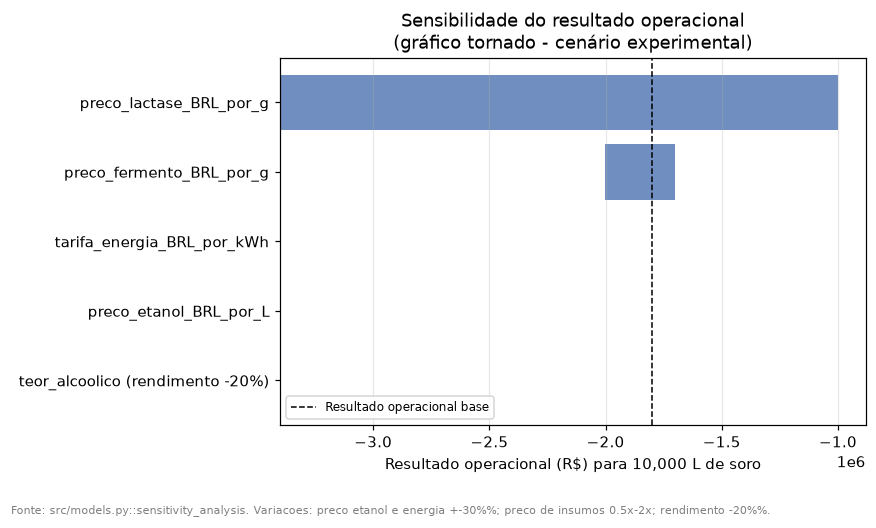

In [5]:
# Monta o grafico tornado: para cada parametro, o range [min, max] do
# resultado operacional entre os multiplicadores testados.
tornado_rows = []
for param in sens["parametro"].unique():
    sub = sens[sens["parametro"] == param]
    tornado_rows.append({
        "parametro": param,
        "min": sub["resultado_operacional_R$"].min(),
        "max": sub["resultado_operacional_R$"].max(),
    })
tornado_rows.append({
    "parametro": "teor_alcoolico (rendimento -20%)",
    "min": min(resultado_base["resultado_operacional_R$"], resultado_menos20["resultado_operacional_R$"]),
    "max": max(resultado_base["resultado_operacional_R$"], resultado_menos20["resultado_operacional_R$"]),
})
tornado = pd.DataFrame(tornado_rows)
tornado["amplitude"] = tornado["max"] - tornado["min"]
tornado = tornado.sort_values("amplitude")

fig, ax = plt.subplots(figsize=(8, 4.5))
y_pos = np.arange(len(tornado))
ax.barh(y_pos, tornado["max"] - tornado["min"], left=tornado["min"], color="#4c72b0", alpha=0.8)
ax.axvline(resultado_base["resultado_operacional_R$"], color="black", linestyle="--", linewidth=1,
           label="Resultado operacional base")
ax.set_yticks(y_pos)
ax.set_yticklabels(tornado["parametro"])
ax.set_xlabel(f"Resultado operacional (R$) para {VOLUME_REF_L:,} L de soro")
ax.set_title("Sensibilidade do resultado operacional\n(gráfico tornado - cenário experimental)")
ax.legend(fontsize=8)
ax.grid(True, axis="x", alpha=0.3)
fig.text(0.01, -0.05,
         "Fonte: src/models.py::sensitivity_analysis. Variacoes: preco etanol e energia +-30%%; preco de insumos 0.5x-2x; rendimento -20%%.",
         fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/fig_tornado_sensibilidade.png", dpi=150, bbox_inches="tight")
plt.show()

**Leitura**: o preço da lactase domina por larga margem — sua faixa de variação (0,5× a 2×) desloca o resultado operacional em dezenas de milhares de reais, enquanto energia e preço do etanol, mesmo variando 30%, mudam o resultado em poucas dezenas de reais. O rendimento (teor alcoólico) tem efeito intermediário: afeta a receita proporcionalmente, mas a receita já é pequena perto do custo, então seu impacto absoluto também é pequeno perto do efeito do preço da enzima.

**Conclusão direta**: a pergunta "esse processo é economicamente viável?" **não pode ser respondida com os dados atuais** — ela se reduz quase inteiramente à pergunta "qual é o preço real da lactase em escala industrial?", que não conseguimos responder com fontes confiáveis (notebook 02).


## Ponto de equilíbrio: o que precisaria mudar?

Primeiro tentamos a pergunta mais direta — "que preço de lactase zeraria o resultado?" — mantendo os demais custos fixos no valor base.

In [6]:
cp = m.CostParams()
custos_base = m.calculate_cost(VOLUME_REF_L, "experimental", cp)
receita_base = m.calculate_revenue(custos_base["etanol_puro_L"], cp.preco_etanol_BRL_por_L)

dose_total_lactase_g = VOLUME_REF_L * cp.lactase_g_por_L_soro
outros_custos = custos_base["custo_fermento_R$"] + custos_base["custo_energia_R$"]

preco_lactase_equilibrio = (receita_base - outros_custos) / dose_total_lactase_g

print(f"Receita total (10.000 L de soro):        R$ {receita_base:,.2f}")
print(f"Custo de fermento + energia (sem lactase): R$ {outros_custos:,.2f}")
print(f"Preço de lactase no ponto de equilíbrio:  R$ {preco_lactase_equilibrio:.5f}/g\n")

if preco_lactase_equilibrio < 0:
    print("O resultado é NEGATIVO - matematicamente impossível (preço não pode ser negativo).")
    print("Isso significa que, mesmo com lactase de graça (custo zero), o processo ainda")
    print("perderia dinheiro: o custo de FERMENTO + ENERGIA sozinho já é maior que a receita.")


Receita total (10.000 L de soro):        R$ 134.70
Custo de fermento + energia (sem lactase): R$ 200,648.33
Preço de lactase no ponto de equilíbrio:  R$ -1.25174/g

O resultado é NEGATIVO - matematicamente impossível (preço não pode ser negativo).
Isso significa que, mesmo com lactase de graça (custo zero), o processo ainda
perderia dinheiro: o custo de FERMENTO + ENERGIA sozinho já é maior que a receita.


Isso muda a pergunta. Em vez de perguntar "que preço de lactase equilibra a conta", vale isolar o custo **mais objetivo** que temos — a energia térmica, que não depende de preço de varejo nem de nenhuma suposição comercial, apenas de física (calor específico + calor latente, notebook 04) — e perguntar: **a receita cobre sequer esse custo, ignorando todos os reagentes?**

In [7]:
custo_energia_base = custos_base["custo_energia_R$"]
razao_energia_receita = custo_energia_base / receita_base

print(f"Custo de energia (fisica, cenario experimental): R$ {custo_energia_base:,.2f}")
print(f"Receita (cenario experimental, teor alcoolico {m.SCENARIOS['experimental']['teor_alcoolico']:.1%}): R$ {receita_base:,.2f}")
print(f"Energia / receita: {razao_energia_receita:.2f}x\n")

# teor_alcoolico e o unico fator que muda linearmente a receita sem mudar o
# custo de energia (que depende dos volumes de soro/mosto/destilado, nao do
# teor alcoolico). Logo, o teor alcoolico "de equilibrio apenas para a
# energia" escala linearmente a partir do cenario base:
teor_base = m.SCENARIOS["experimental"]["teor_alcoolico"]
teor_breakeven_energia = teor_base * razao_energia_receita

print(f"Teor alcoolico necessario so para cobrir o custo de ENERGIA (ignorando reagentes): {teor_breakeven_energia:.1%} v/v")
print(f"Para comparacao, a faixa esperada pelo proprio projeto (relatorio, secao 4.6) e de 5% a 12% v/v.")


Custo de energia (fisica, cenario experimental): R$ 648.33
Receita (cenario experimental, teor alcoolico 8.5%): R$ 134.70
Energia / receita: 4.81x

Teor alcoolico necessario so para cobrir o custo de ENERGIA (ignorando reagentes): 40.9% v/v
Para comparacao, a faixa esperada pelo proprio projeto (relatorio, secao 4.6) e de 5% a 12% v/v.


**Este é o achado mais robusto do modelo econômico**, porque não depende do preço de varejo questionável de lactase/fermento — depende só de física e do preço de mercado do etanol, os dois dados mais confiáveis que temos. Ele mostra que o gargalo não é "só" o preço da enzima: é que o processo, como caracterizado no experimento, produz uma solução **muito diluída** (o destilado já é só 9,4% do mosto, e dele só uma fração de 5-12% é etanol). Isso significa aquecer e destilar um volume grande de líquido — majoritariamente água — para recuperar uma quantidade pequena de etanol. O custo de energia escala com o **volume total processado**; a receita escala com o **teor alcoólico**, que é baixo.

Isso não invalida a rota química (a hidrólise + fermentação funcionou, o teste de chama comprova), mas indica que, para haver viabilidade econômica, seria necessário **aumentar a concentração final de etanol** (fermentação mais eficiente, menos diluição, talvez concentração do soro antes de fermentar) — não apenas negociar um preço melhor de enzima. Com os dados que temos, **não é possível quantificar se isso é alcançável**, mas é uma direção de pesquisa mais promissora do que apenas "comprar lactase mais barata".


## Simulação de Monte Carlo — apenas para o preço do etanol

Diferente dos demais parâmetros, o preço do etanol tem uma distribuição real observável: o indicador CEPEA/Esalq variou +7,3% em uma única semana (E12). Usamos essa evidência para simular uma distribuição uniforme plausível (R$ 1,80–3,40/L, cobrindo tanto quedas quanto altas de preço observadas historicamente no mercado de etanol) — **não** para os preços de insumo, cuja incerteza não tem base de distribuição conhecida (ver docstring de `monte_carlo_simulation` em `src/models.py`).


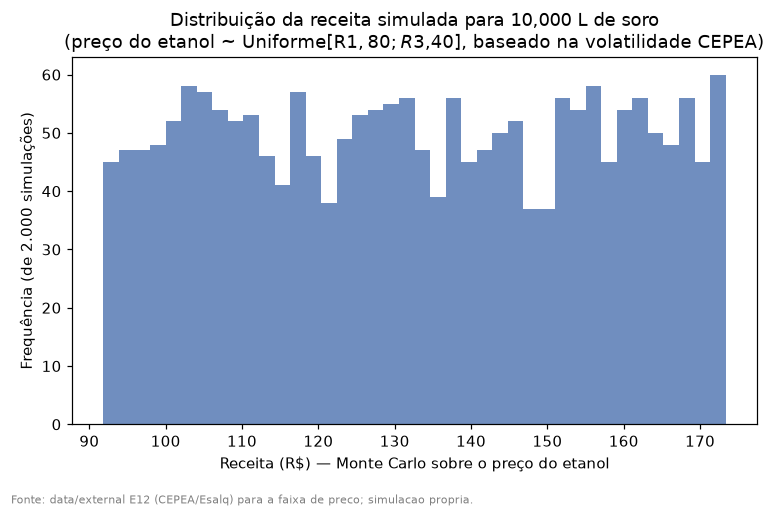

count    2000.000000
mean      132.831476
std        23.700625
min        91.842330
25%       111.716162
50%       132.274520
75%       153.914974
max       173.352828
Name: receita_R$, dtype: float64


In [8]:
mc = m.monte_carlo_simulation(
    VOLUME_REF_L, "experimental", n_simulations=2000,
    param_distributions={"preco_etanol_BRL_por_L": (1.80, 3.40)},
)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(mc["receita_R$"], bins=40, color="#4c72b0", alpha=0.8)
ax.set_xlabel("Receita (R$) — Monte Carlo sobre o preço do etanol")
ax.set_ylabel("Frequência (de 2.000 simulações)")
ax.set_title(f"Distribuição da receita simulada para {VOLUME_REF_L:,} L de soro\n(preço do etanol ~ Uniforme[R$1,80; R$3,40], baseado na volatilidade CEPEA)")
fig.text(0.01, -0.03, "Fonte: data/external E12 (CEPEA/Esalq) para a faixa de preco; simulacao propria.", fontsize=7, color="gray")
plt.tight_layout()
plt.savefig("../reports/figures/fig_montecarlo_receita.png", dpi=150, bbox_inches="tight")
plt.show()

print(mc["receita_R$"].describe())

Mesmo no limite superior da faixa simulada (R$ 3,40/L), a receita para 10.000 L de soro fica na casa de poucas dezenas de reais — muito abaixo do custo de lactase de varejo (~R$ 1,6 milhão para o mesmo volume, ver notebook 04). A incerteza do preço do etanol é real, mas **irrelevante perto da incerteza do preço da enzima** — outra forma de ver a mesma conclusão do gráfico tornado.


## Resumo da análise de sensibilidade

1. **O achado mais robusto não depende de preço de varejo**: mesmo usando só o custo de energia (calculado por física, não por preço de mercado) contra a receita ao preço real do etanol (CEPEA), o custo de energia sozinho já supera a receita em ~4,8×. Seria necessário um teor alcoólico de ~41% v/v só para cobrir a energia — bem acima da faixa de 5-12% que o próprio projeto espera antes de qualquer retificação.
2. O preço de varejo de lactase e fermento, individualmente, já são maiores que a receita — nenhum dos dois isoladamente permite equilíbrio, então o "preço de equilíbrio da lactase" isolado não é uma pergunta bem colocada (dá resultado negativo, sem significado físico).
3. Preço do etanol e tarifa de energia (dentro de variações realistas de mercado) têm efeito pequeno perto da escala do problema.
4. O modelo é **invariante à escala** (não modela custos fixos/CAPEX) — aumentar o volume de soro, isoladamente, não muda a conclusão de viabilidade neste modelo.
5. **A direção mais promissora para viabilidade não é negociar preço de insumo — é aumentar a concentração final de etanol** (menos diluição do processo), algo que este projeto não testou e que não pode ser quantificado com os dados disponíveis.

Seguimos para `06_final_results`, que consolida os achados de todos os notebooks em uma conclusão final.
